In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv('../eda-project-real-estate/KC_housing_data.csv')

print(df.eq(0).sum())

date                0
price              49
bedrooms            2
bathrooms           2
sqft_living         0
sqft_lot            0
floors              0
waterfront       4567
view             4140
condition           0
sqft_above          0
sqft_basement    2745
yr_built            0
yr_renovated     2735
street              0
city                0
statezip            0
country             0
dtype: int64


In [5]:
df = df[df['price'] != 0]
df = df[df['bedrooms'] != 0]
df = df[df['bathrooms'] != 0]

print(df.eq(0).sum())

date                0
price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       4519
view             4102
condition           0
sqft_above          0
sqft_basement    2716
yr_built            0
yr_renovated     2706
street              0
city                0
statezip            0
country             0
dtype: int64


Task 1 \
Linear Regression: Predicting House Prices
- Load the housing dataset.
- Visualize key features vs target price.
- Split data into train and test sets.
- Fit a Linear Regression model to predict house prices.
- Predict on test data and compute Mean Squared Error (MSE).
- Plot true vs predicted house prices.
- Interpret what the MSE says about model accuracy.

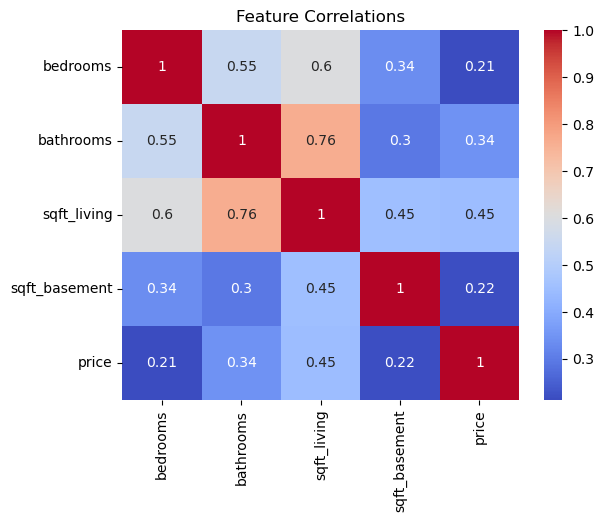

In [6]:
# 1. Key Features vs Target Price

key_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_basement']

corr = df[key_features + ['price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

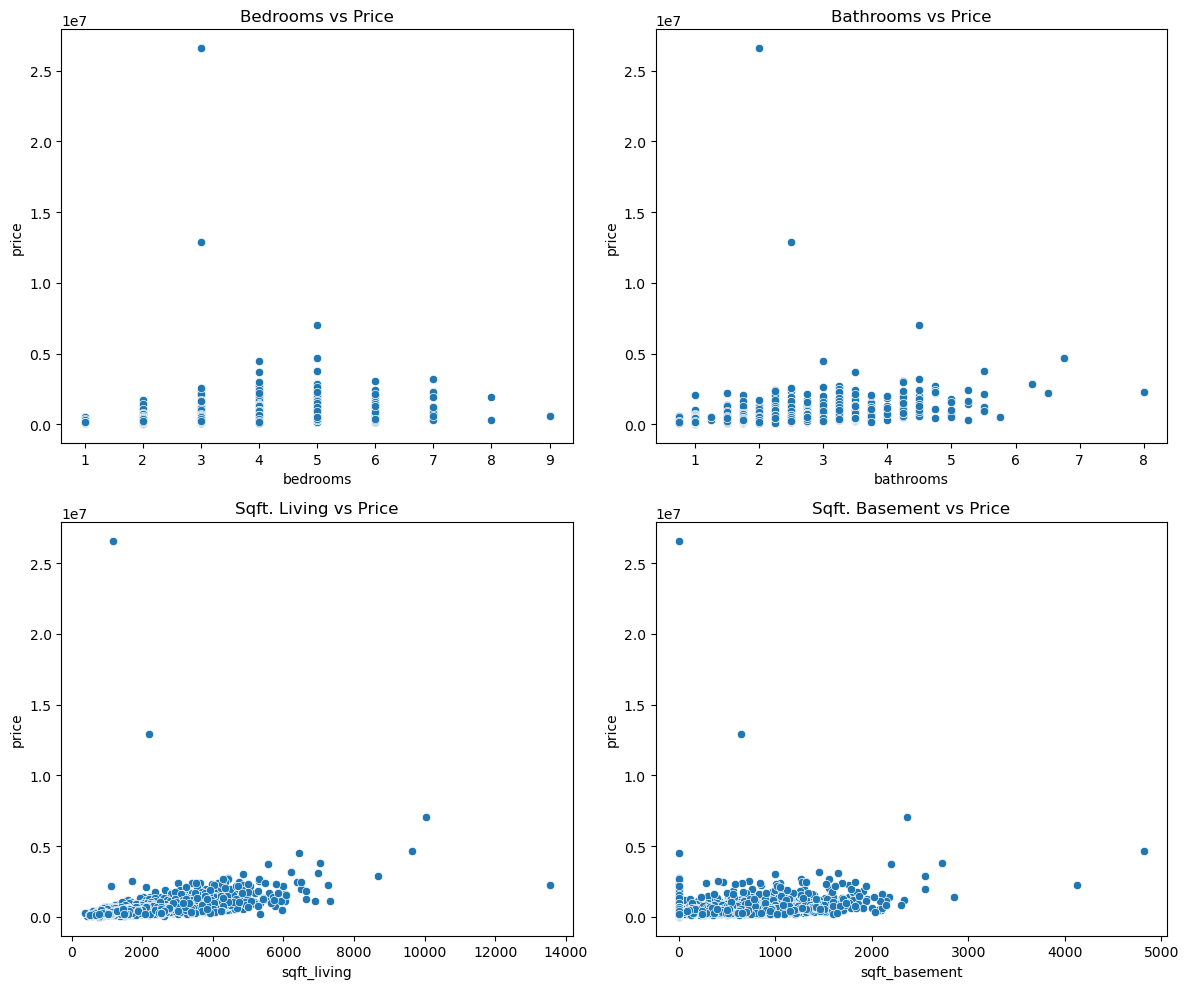

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(12,10))

sns.scatterplot(data=df, x='bedrooms', y='price', ax=ax[0,0])
ax[0,0].set_title('Bedrooms vs Price')

sns.scatterplot(data=df, x='bathrooms', y='price', ax=ax[0,1])
ax[0,1].set_title('Bathrooms vs Price')

sns.scatterplot(data=df, x='sqft_living', y='price', ax=ax[1,0])
ax[1,0].set_title('Sqft. Living vs Price')

sns.scatterplot(data=df, x='sqft_basement', y='price', ax=ax[1,1])
ax[1,1].set_title('Sqft. Basement vs Price')

plt.tight_layout()
plt.show()

In [15]:
# 2. Train and test data sets
X = df[['sqft_living']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit a linear regression model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# 4. Predict on test data and compute Mean Squared Error (MSE)
lin_pred = lin_model.predict(X_test);

mse = mean_squared_error(y_test, lin_pred)
print("Linear Regression mean squared error:", mse)

Linear Regression mean squared error: 76208855246.8951


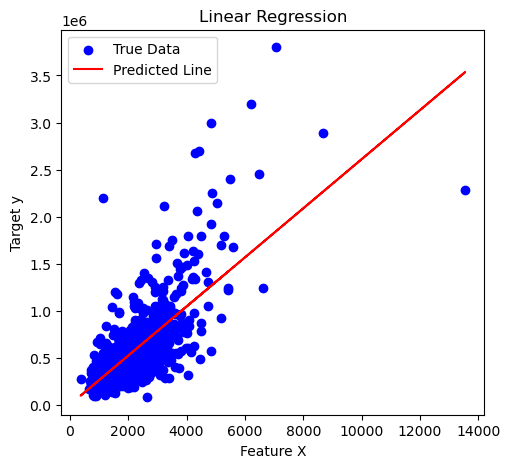

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_test, y_test, color='blue', label='True Data')
plt.plot(X_test, lin_pred, color='red', label='Predicted Line')
plt.title('Linear Regression')
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.legend()

Tasks 2 \
Logistic Regression: Classifying Expensive Houses
- Create a new binary target variable:
    - 1 if house price is above median price, else 0.
- Split data into train and test sets.
- Fit a Logistic Regression model to predict this binary label.
- Predict on test data and compute classification accuracy.
- Visualize confusion matrix or ROC curve.
- Discuss when logistic regression is useful compared to linear.

Task 3
Comparison and Reflection
- Summarize differences in outputs, tasks, and metrics of the two models.
- Discuss real-world use cases for predicting prices vs classifying expensive houses.
- Optionally, experiment with features and see how adding/removing features affects both models.